# Keyword Detection (TensorFlow)
This notebook contains the TensorFlow implementation of the Keyword Detection model with GPU support.

## Loading Requirements

In [48]:
import wave
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from sklearn.model_selection import train_test_split

## 0. Check GPU Availability


In [49]:
def check_gpu_status():
    gpus = tf.config.list_physical_devices('GPU')
    print(f"CUDA Available: {len(gpus) > 0}")
    if gpus:
        print(f"Number of GPUs detected: {len(gpus)}\n")
        for i, gpu in enumerate(gpus):
            print(f"--- Available GPUs: {i} ---")
            print(f"Name: {gpu.name}")
    else:
        print("TensorFlow cannot detect a compatible GPU. It will default to CPU.")

check_gpu_status()

CUDA Available: False
TensorFlow cannot detect a compatible GPU. It will default to CPU.


## 1. Get Audio File Specifications


In [50]:
def check_wav_specs_tf(file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return
    
    audio_bin = tf.io.read_file(file_path)

    audio, sample_rate = tf.audio.decode_wav(audio_bin, desired_channels=-1)
    
    # audio shape is [samples, channels]
    num_samples = tf.shape(audio)[0].numpy()
    num_channels = tf.shape(audio)[1].numpy()
    sample_rate = sample_rate.numpy()
    duration = num_samples / sample_rate

    print(f"Sample Rate: {sample_rate} Hz")
    print(f"Channels: {num_channels}")
    print(f"Frames (Samples): {num_samples}")
    print(f"Duration: {duration:.2f} seconds")
    
check_wav_specs_tf("../dataset/yes/1a673010_nohash_1.wav")

Sample Rate: 16000 Hz
Channels: 1
Frames (Samples): 16000
Duration: 1.00 seconds


## 2. Data Preparation

In [51]:
import json
import os
from sklearn.model_selection import train_test_split

path_to_config = os.path.join('..', 'config.json')

try:
    with open(path_to_config, 'r') as f:
        config = json.load(f)
    print("Konfiguration erfolgreich geladen!")
except FileNotFoundError:
    print(f"Fehler: Datei nicht gefunden unter {os.path.abspath(path_to_config)}")
    raise

CLASSES = config["keywords"]
DATA_DIR = os.path.join('..', config["DATA_DIR"])
NUM_SAMPLES = config["num_samples"]
TARGET_SAMPLE_RATE = config["target_sample_rate"]
BATCH_SIZE = 32


def get_files_and_labels():
    file_paths = []
    labels = []
    class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASSES)}

    for cls_name in CLASSES:
        cls_dir = os.path.join(DATA_DIR, cls_name)
        if not os.path.exists(cls_dir):
            print(f"Warnung: Verzeichnis {cls_dir} nicht gefunden.")
            continue
        for file in os.listdir(cls_dir):
            if file.endswith(".wav"):
                file_paths.append(os.path.join(cls_dir, file))
                labels.append(class_to_idx[cls_name])
    return file_paths, labels


file_paths, labels = get_files_and_labels()

if len(file_paths) > 0:
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        file_paths, labels, test_size=0.2, stratify=labels, random_state=42
    )

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.125, stratify=train_val_labels, random_state=42
    )

    print(f"Erfolg: {len(file_paths)} Dateien gefunden.")
    print(f"-> Training:   {len(train_paths)} (70%)")
    print(f"-> Validation: {len(val_paths)} (10%)")
    print(f"-> Test:       {len(test_paths)} (20%)")
else:
    print(f"Keine Dateien gefunden! Gesuchter Pfad: {os.path.abspath(DATA_DIR)}")

Konfiguration erfolgreich geladen!
Warnung: Verzeichnis ..\dataset/other nicht gefunden.
Erfolg: 9486 Dateien gefunden.
-> Training:   6639 (70%)
-> Validation: 949 (10%)
-> Test:       1898 (20%)


## 3. Dataset Pipeline (TensorFlow native audio layer)

In [52]:
## 3. Dataset Pipeline (TensorFlow native audio layer)

import tensorflow as tf


@tf.function
def process_path(file_path, label):
    # Read and decode wav
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # Pad or cut to exactly NUM_SAMPLES
    audio_length = tf.shape(audio)[0]
    padding = tf.maximum(NUM_SAMPLES - audio_length, 0)
    audio = tf.pad(audio, [[0, padding]])
    audio = audio[:NUM_SAMPLES]

    return audio, label

def extract_mfcc(audio):

    stft = tf.signal.stft(
        audio,
        frame_length=256,
        frame_step=128
    )

    spectrogram = tf.abs(stft)

    mel_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=40,
        num_spectrogram_bins=spectrogram.shape[-1],
        sample_rate=16000
    )

    mel_spectrogram = tf.matmul(
        spectrogram,
        mel_matrix
    )

    log_mel = tf.math.log(
        mel_spectrogram + 1e-6
    )

    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(
        log_mel
    )

    mfccs = mfccs[..., :13]

    mfccs = tf.expand_dims(
        mfccs,
        axis=-1
    )

    return mfccs



def create_dataset(paths, labels, batch_size, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths))

    dataset = dataset.map(
        process_path,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.map(
        lambda x, y: (extract_mfcc(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


# Erstelle die drei Datasets
train_ds = create_dataset(train_paths, train_labels, BATCH_SIZE, shuffle=True)
val_ds = create_dataset(val_paths, val_labels, BATCH_SIZE, shuffle=False)
test_ds = create_dataset(test_paths, test_labels, BATCH_SIZE, shuffle=False)

print("Alle drei TensorFlow Datasets (Train, Val, Test) wurden erfolgreich erstellt.")

Alle drei TensorFlow Datasets (Train, Val, Test) wurden erfolgreich erstellt.


## 4. Model Architecture (with onboard MelSpectrogram on GPU)

In [53]:
# Mel spectrogram parameters mapping to 64 mels equivalent
frame_length = 1024
frame_step = 512
fft_length = 1024
num_mel_bins = 64
lower_edge_hertz = 80.0
upper_edge_hertz = 7600.0


def build_model(num_classes):

    mfcc_input = tf.keras.Input(
        shape=(124, 13, 1),
        name='mfcc_input'
    )

    x = mfcc_input

    x = tf.keras.layers.Conv2D(
        16, 3,
        padding='same',
        activation='relu'
    )(x)

    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(
        32, 3,
        padding='same',
        activation='relu'
    )(x)

    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(
        64, 3,
        padding='same',
        activation='relu'
    )(x)

    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Resizing(4, 4)(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation='relu'
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        num_classes
    )(x)

    return tf.keras.Model(
        inputs=mfcc_input,
        outputs=outputs
    )

model = build_model(len(CLASSES))
model.summary()

print(model.input_shape)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 124, 13, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 124, 13, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 62, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 62, 6, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 31, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 31, 3, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_5 (Resizing)           │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,141 (606.02 KB)

 Trainable params: 155,141 (606.02 KB)

 Non-trainable params: 0 (0.00 B)

(None, 124, 13, 1)


## 5. Training Loop

In [54]:
LEARNING_RATE = 0.001
EPOCHS = 20

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

print(f"Starte Training für {EPOCHS} Epochen...")
print("TensorFlow nutzt automatisch die GPU, falls vorhanden.")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Starte Training für 20 Epochen...
TensorFlow nutzt automatisch die GPU, falls vorhanden.
Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5852 - loss: 1.0401 - val_accuracy: 0.8145 - val_loss: 0.5030
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8241 - loss: 0.4833 - val_accuracy: 0.8630 - val_loss: 0.3966
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.8783 - loss: 0.3505 - val_accuracy: 0.8662 - val_loss: 0.3596
Epoch 4/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9057 - loss: 0.2739 - val_accuracy: 0.9073 - val_loss: 0.2808
Epoch 5/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9191 - loss: 0.2299 - val_accuracy: 0.9178 - val_loss: 0.2356
Epoch 6/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9333 - loss: 0.1892 - val_accuracy: 0.8957 - val_loss: 0.3170
Epoch 7/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9416 - loss: 0.1589 - val_accuracy: 0.9220 - val_loss: 0.2555
Epoch 

## 6. Visualization

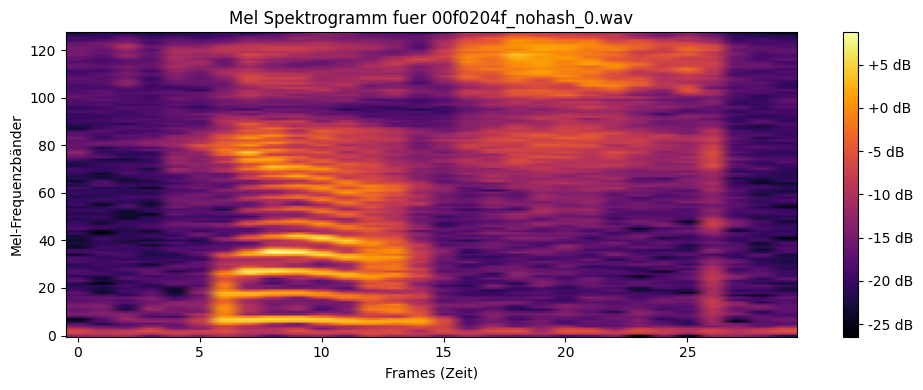

In [55]:
file_path = '../dataset/yes/00f0204f_nohash_0.wav'

if os.path.exists(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # STFT - Nutzt die Parameter von oben
    stfts = tf.signal.stft(audio, frame_length=frame_length, frame_step=frame_step, fft_length=fft_length)
    spectrograms = tf.abs(stfts)

    # Mel Spectrogram
    mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        128, spectrograms.shape[-1], TARGET_SAMPLE_RATE, lower_edge_hertz, upper_edge_hertz)
    mel_spectrograms = tf.tensordot(spectrograms, mel_weight_matrix, 1)

    # Amplitude to DB (log)
    log_mel_spectrogram = 10.0 * tf.math.log(tf.maximum(mel_spectrograms, 1e-10)) / tf.math.log(10.0)

    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(log_mel_spectrogram).numpy(), cmap='inferno', origin='lower', aspect='auto')
    plt.title(f'Mel Spektrogramm fuer {os.path.basename(file_path)}')
    plt.xlabel('Frames (Zeit)')
    plt.ylabel('Mel-Frequenzbänder')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
else:
    print(f"Datei {file_path} nicht gefunden. Bitte Pfad prüfen!")

## 7. Evaluation & Inference

Starte finale Evaluation auf den Testdaten...
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9189 - loss: 0.2247

FINALE TEST-GENAUIGKEIT: 91.89%
Generiere Vorhersagen für die Confusion Matrix...


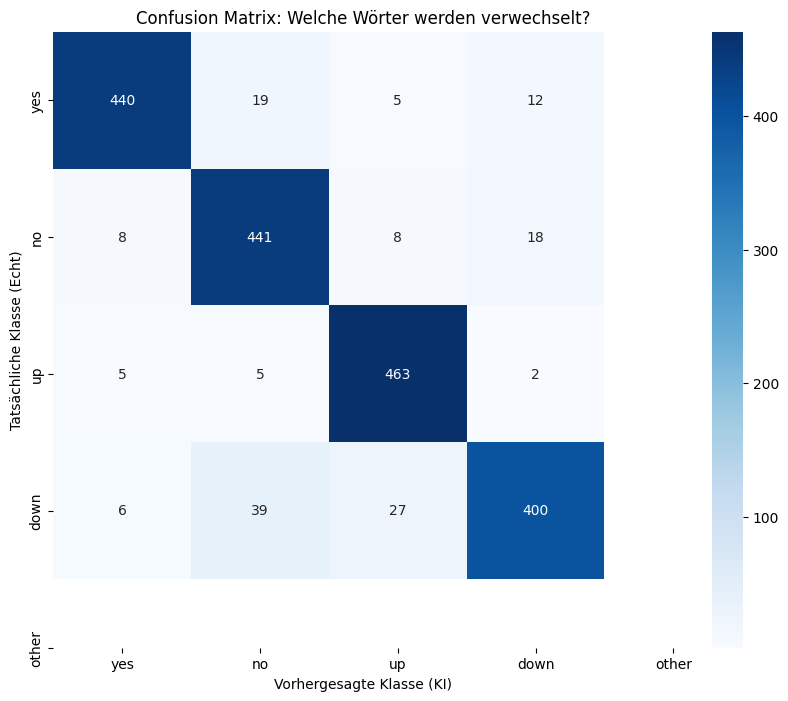

Konvertiere Modell in ONNX...


ValueError: in user code:

    File "c:\Users\nikna\Desktop\KeywordDetection\.venv\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\nikna\Desktop\KeywordDetection\.venv\Lib\site-packages\keras\src\layers\input_spec.py", line 245, in assert_input_compatibility
        raise ValueError(

    ValueError: Input 0 with name 'mfcc_input' of layer 'functional_5' is incompatible with the layer: expected shape=(None, 124, 13, 1), found shape=(None, 16000)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tf2onnx
import tensorflow as tf

print("Starte finale Evaluation auf den Testdaten...")
test_results = model.evaluate(test_ds, return_dict=True)
print(f"\nFINALE TEST-GENAUIGKEIT: {test_results['accuracy'] * 100:.2f}%")

# 2. Confusion Matrix (Detaillierte Fehleranalyse)
y_pred = []
y_true = []

print("Generiere Vorhersagen für die Confusion Matrix...")
for audio, label in test_ds:
    preds = model.predict(audio, verbose=0)
    y_pred.extend(tf.argmax(preds, axis=1).numpy())
    y_true.extend(label.numpy())

# Matrix berechnen
cm = confusion_matrix(y_true, y_pred)

# Plotten der Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Vorhergesagte Klasse (KI)')
plt.ylabel('Tatsächliche Klasse (Echt)')
plt.title('Confusion Matrix: Welche Wörter werden verwechselt?')
plt.show()

print("Konvertiere Modell in ONNX...")

input_signature = [
    tf.TensorSpec(
        [None, 124, 13, 1],
        tf.float32,
        name="mfcc_input"
    )
]

onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=input_signature,
    opset=18
)

onnx_save_path = "Models/TensorFlow.onnx"

with open(onnx_save_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"ERFOLG: Modell wurde unter {onnx_save_path} gespeichert.")

In [ ]:
import onnxruntime as ort

session = ort.InferenceSession(
    "Models/TensorFlow.onnx",
    providers=["CPUExecutionProvider"]
)

print("ONNX geladen")
print(session.get_inputs())
print(session.get_outputs())

InvalidGraph: [ONNXRuntimeError] : 10 : INVALID_GRAPH : Load model from Models/TensorFlow.onnx failed:This is an invalid model. In Node, ("functional_2_1/mel_spectrogram_2_1/Abs", ComplexAbs, "", -1) : ("CPLX_Reshape_functional_2_1/mel_spectrogram_2_1/stft/rfftrfft__404:0": tensor(float),) -> ("functional_2_1/mel_spectrogram_2_1/Abs:0",) , Error No Op registered for ComplexAbs with domain_version of 18

## 8. Einzelauswertung der Testdateien

In [ ]:
for i, file_path in enumerate(test_paths):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # Padding/Cutting auf NUM_SAMPLES
    audio_length = tf.shape(audio)[0]
    padding = tf.maximum(NUM_SAMPLES - audio_length, 0)
    audio = tf.pad(audio, [[0, padding]])
    audio = audio[:NUM_SAMPLES]

    input_tensor = tf.expand_dims(audio, axis=0)
    prediction_logits = model.predict(input_tensor, verbose=0)

    probabilities = tf.nn.softmax(prediction_logits[0])
    predicted_idx = tf.argmax(probabilities).numpy()
    confidence = probabilities[predicted_idx].numpy()

    true_idx = test_labels[i]
    true_label = CLASSES[true_idx]

    file_name = os.path.basename(file_path)

    print(f"{file_name:<40} | {true_label:<15} | {CLASSES[predicted_idx]:<15} | {confidence*100:>6.2f}%")

    if i >= 250:
        print("...")
        break

6d1dcca6_nohash_0.wav                    | no              | no              | 100.00%
cb2929ce_nohash_2.wav                    | yes             | yes             |  99.99%
765ffccb_nohash_0.wav                    | yes             | yes             | 100.00%
173ce2be_nohash_0.wav                    | no              | no              |  97.03%
aa48c94a_nohash_0.wav                    | yes             | yes             |  73.41%
aac5b7c1_nohash_0.wav                    | yes             | yes             |  99.98%
7846fd85_nohash_0.wav                    | up              | up              |  99.86%
da15e796_nohash_2.wav                    | down            | down            |  99.69%
e7ea8b76_nohash_1.wav                    | down            | down            | 100.00%
f5733968_nohash_4.wav                    | down            | down            |  99.69%
708b8d51_nohash_0.wav                    | yes             | yes             | 100.00%
bdb90d38_nohash_1.wav                    | 